LIBRARIES

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

STEP 2: DATA LOADING

In [47]:
df = pd.read_csv(r'C:\Users\hp\Downloads/Processed_Flipdata - Processed_Flipdata.csv')


STEP 3: DATA EXPLORATION

In [48]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [49]:
df.shape

(541, 12)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [51]:
df.describe()


,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000


STEP 4: DATA PREPROCESSING

In [52]:
# Cleaning String to Numeric
df['Prize'] = df['Prize'].str.replace(',', '').astype(float)
df['Rear Camera'] = df['Rear Camera'].str.replace('MP', '').astype(float)
df['Front Camera'] = df['Front Camera'].str.replace('MP', '').astype(float)


In [53]:
#  Handle Outliers (IQR Method)
Q1 = df['Prize'].quantile(0.25)
Q3 = df['Prize'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Prize'] < (Q1 - 1.5 * IQR)) | (df['Prize'] > (Q3 + 1.5 * IQR)))]

In [54]:
# Missing Values
df = df.dropna()

In [55]:
#Categorical Encoding 
le = LabelEncoder()
df['Model'] = le.fit_transform(df['Model'])
df['Colour'] = le.fit_transform(df['Colour'])

In [56]:
# Processor One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Processor_'], drop_first=True)

In [57]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,18,152,64,4,6000,13.0,5.0,1,16.76,Unisoc Spreadtrum SC9863A1,7299.0
1,1,18,19,64,4,6000,13.0,5.0,1,16.76,Unisoc Spreadtrum SC9863A1,7299.0
2,2,30,142,128,8,5000,50.0,16.0,0,16.64,Qualcomm Snapdragon 680,11999.0
3,3,62,192,32,2,5000,8.0,5.0,0,16.56,Mediatek Helio A22,5649.0
4,4,7,124,128,8,5000,50.0,5.0,1,16.76,G37,8999.0


In [58]:
df.shape

(516, 12)

STEP 5: FEATURE EXTRACTION ANALYSIS


In [59]:
X = df_encoded.drop(['Prize'], axis=1)
y = df_encoded['Prize']

In [60]:
# Feature significance 
selector = ExtraTreesRegressor(n_estimators=100, random_state=42)
selector.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

STEP 6: MODEL BUILDING & PREDICTION 

In [61]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [62]:
# Evaluation Results
print(f"\n--- Model Performance Report ---")
print(f"R2 Score (Accuracy): {r2_score(y_test, y_pred) * 100:.2f}%")
print(f"Mean Absolute Error: ₹{mean_absolute_error(y_test, y_pred):.2f}")


--- Model Performance Report ---
R2 Score (Accuracy): 92.83%
Mean Absolute Error: ₹1035.29


 STEP 7: COMPREHENSIVE REPORT & VISUALS

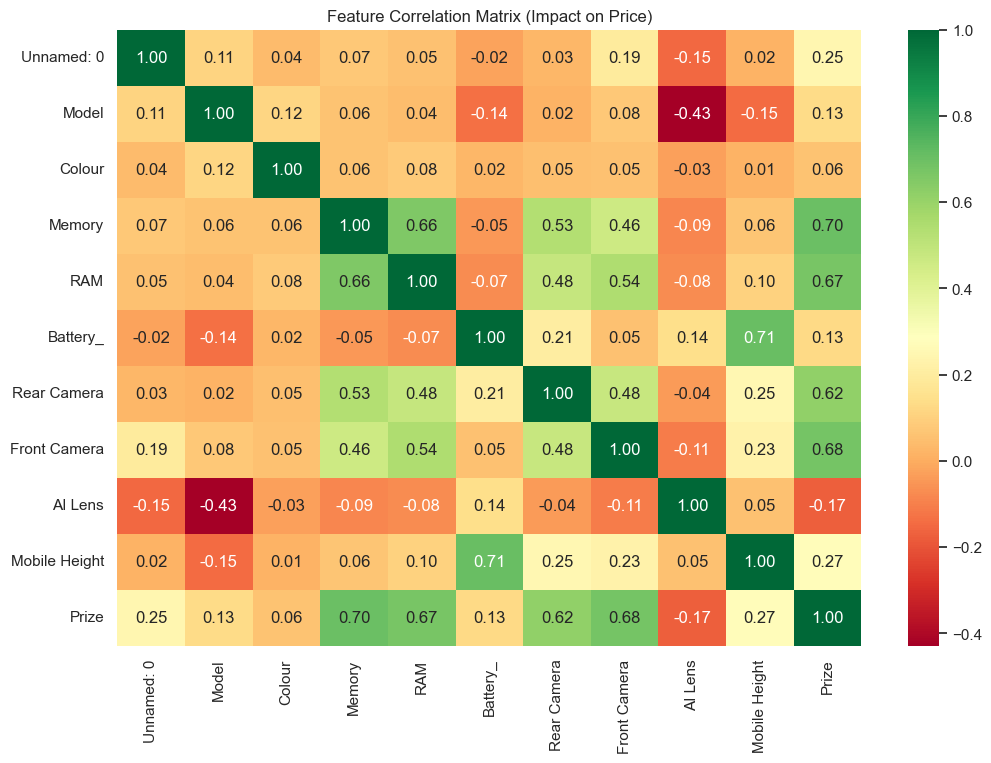

In [63]:
# Heatmap: Correlation Analysis
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Matrix (Impact on Price)')
plt.show()

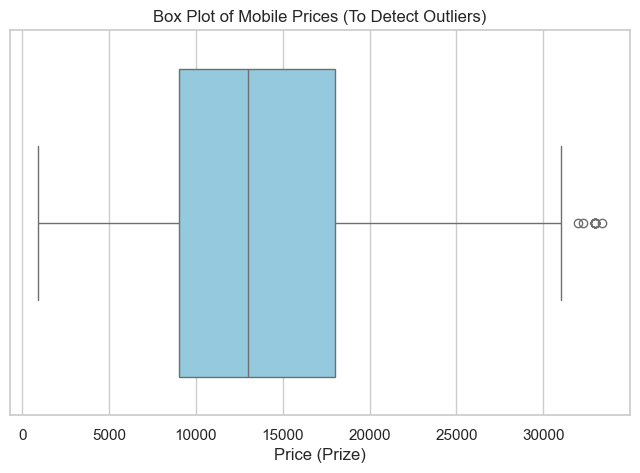

C:\Users\hp\AppData\Local\Temp\ipykernel_18356\63694176.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RAM', y='Prize', data=df, palette='Set2')


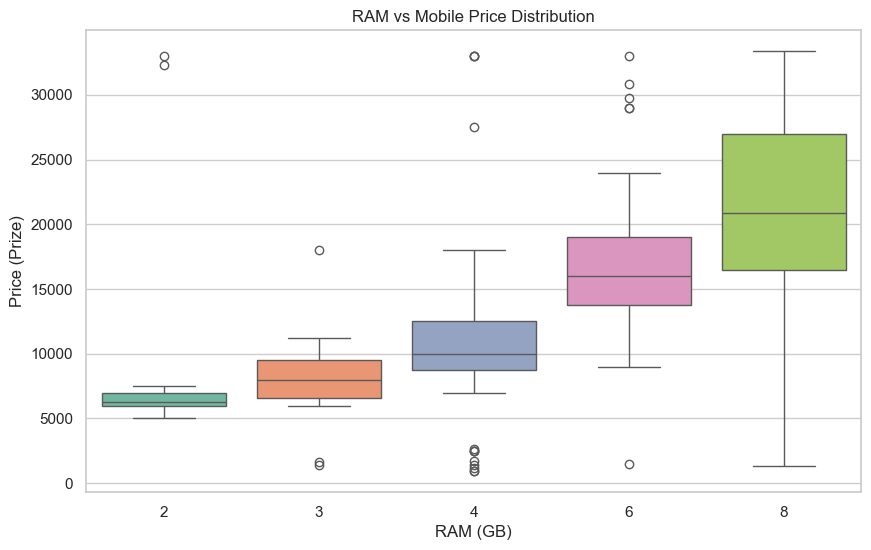

C:\Users\hp\AppData\Local\Temp\ipykernel_18356\63694176.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Memory', y='Prize', data=df, palette='Pastel1')


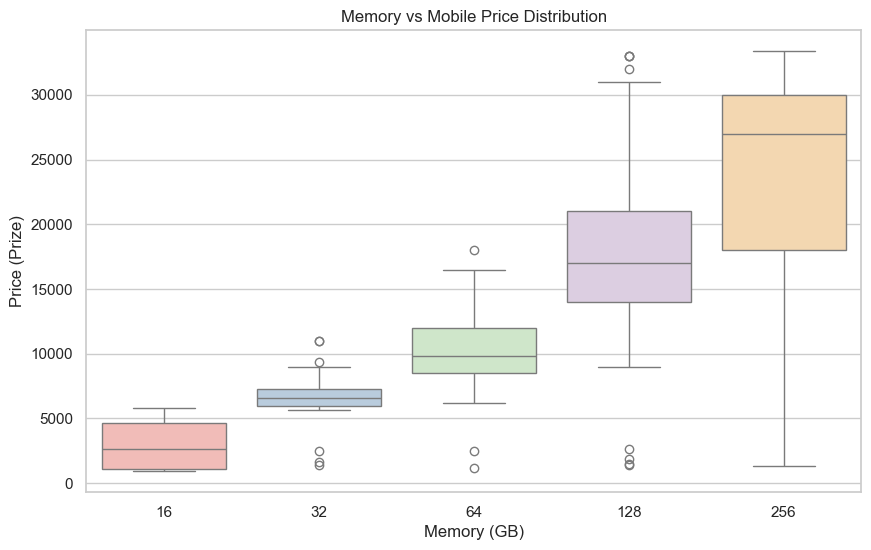

In [64]:

sns.set(style="whitegrid")

# 1. Single Box Plot 
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Prize'], color='skyblue')
plt.title('Box Plot of Mobile Prices (To Detect Outliers)')
plt.xlabel('Price (Prize)')
plt.show()

# 2. Comparison Box Plot (RAM vs Prize)
plt.figure(figsize=(10, 6))
sns.boxplot(x='RAM', y='Prize', data=df, palette='Set2')
plt.title('RAM vs Mobile Price Distribution')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (Prize)')
plt.show()

# 3. Comparison Box Plot (Memory vs Prize)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Memory', y='Prize', data=df, palette='Pastel1')
plt.title('Memory vs Mobile Price Distribution')
plt.xlabel('Memory (GB)')
plt.ylabel('Price (Prize)')
plt.show()

STEP 8: RECOMMENDATIONS

In [65]:
# Example: if you have a DataFrame of feature importances
feature_importance = model.feature_importances_

# Convert to Series with feature names as index
importance_series = pd.Series(feature_importance, index=X.columns)

# Sort and take top 10
top_10 = importance_series.sort_values(ascending=False).head(10)


In [45]:
print("\n--- FINAL RECOMMENDATIONS FOR THE ORGANIZATION ---")
print(f"1. The most influential feature is '{top_10.index[0]}'. Pricing strategy should focus on this.")
print(f"2. After RAM and Memory, '{top_10.index[1]}' has a significant impact on price.")
print("3. The scientific impact of AI Lens and Mobile Height has been analyzed.")



--- FINAL RECOMMENDATIONS FOR THE ORGANIZATION ---
1. The most influential feature is 'Front Camera'. Pricing strategy should focus on this.
2. After RAM and Memory, 'Battery_' has a significant impact on price.
3. The scientific impact of AI Lens and Mobile Height has been analyzed.
